## Arquivos

In [115]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from lightkurve import read
import torch

base_dir = Path('../dados')

#contagem de + e - em cada divisão (train, validation, test)
splits = ['train', 'validation', 'test']
classes = ['positives', 'negatives']
total_geral = 0

for split in splits:
    print(f"\n[{split.upper()}]")
    for cls in classes:
        caminho_pasta = base_dir / split / cls
        
        if caminho_pasta.exists():
            # Conta todos os .fits na pasta
            qtd = len(list(caminho_pasta.glob('*.fits')))
            total_geral += qtd
            print(f" {cls.capitalize()}: {qtd} curvas de luz")
        else:
            print(f" {cls.capitalize()}: PASTA NÃO ENCONTRADA ({caminho_pasta})")

print(f"\nTotal geral de curvas no projeto: {total_geral}\n")


[TRAIN]
 Positives: 840 curvas de luz
 Negatives: 766 curvas de luz

[VALIDATION]
 Positives: 190 curvas de luz
 Negatives: 169 curvas de luz

[TEST]
 Positives: 198 curvas de luz
 Negatives: 155 curvas de luz

Total geral de curvas no projeto: 2318



In [116]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from lightkurve import read
import torch

base_dir = Path('../data/spoc_transit_experiment')

#contagem de + e - em cada divisão (train, validation, test)
splits = ['train', 'validation', 'test']
classes = ['positives', 'negatives']
total_geral = 0

for split in splits:
    print(f"\n[{split.upper()}]")
    for cls in classes:
        caminho_pasta = base_dir / split / cls
        
        if caminho_pasta.exists():
            # Conta todos os .fits na pasta
            qtd = len(list(caminho_pasta.glob('*.fits')))
            total_geral += qtd
            print(f" {cls.capitalize()}: {qtd} curvas de luz")
        else:
            print(f" {cls.capitalize()}: PASTA NÃO ENCONTRADA ({caminho_pasta})")

print(f"\nTotal geral de curvas no projeto: {total_geral}\n")


[TRAIN]
 Positives: 1301 curvas de luz
 Negatives: 6000 curvas de luz

[VALIDATION]
 Positives: 200 curvas de luz
 Negatives: 600 curvas de luz

[TEST]
 Positives: 200 curvas de luz
 Negatives: 600 curvas de luz

Total geral de curvas no projeto: 8901



## NaNs e número de pontos

 Arquivo de exemplo selecionado: ../dados/train/positives/TIC_199376584.fits



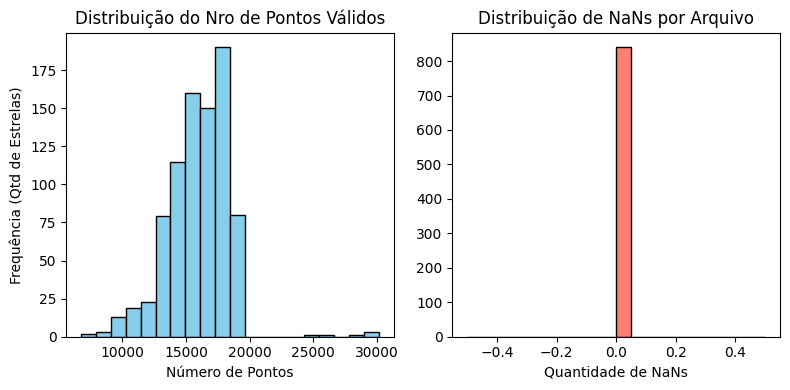

Tamanho Médio (sem NaNs): 16069 pontos
Tamanho Mínimo: 6757 pontos
Tamanho Máximo: 30147 pontos


In [117]:
pasta_alvo = Path('../dados/train/positives')
arquivos = list(pasta_alvo.glob('*.fits'))

if len(arquivos) == 0:
    print(" ERRO:")
else:
    exemplo_path = str(arquivos[0])
    print(f" Arquivo de exemplo selecionado: {exemplo_path}\n")

    tamanhos_brutos = []
    total_nans_lista = []

    # amostra
    amostra = arquivos[:1000] if len(arquivos) > 1000 else arquivos

    for path in amostra:
        lc = read(str(path))
        fluxos = lc.flux.value
        
        # verifica NaNs
        nans = np.isnan(fluxos).sum()
        total_nans_lista.append(nans)
        
        # verifica tamanho real (sem NaNs)
        tamanhos_brutos.append(len(fluxos) - nans)

    plt.figure(figsize=(8, 4))

    # Distribuição dos Tamanhos
    plt.subplot(1, 2, 1)
    plt.hist(tamanhos_brutos, bins=20, color='skyblue', edgecolor='black')
    plt.title('Distribuição do Nro de Pontos Válidos')
    plt.xlabel('Número de Pontos')
    plt.ylabel('Frequência (Qtd de Estrelas)')

    # Quantidade de NaNs
    plt.subplot(1, 2, 2)
    plt.hist(total_nans_lista, bins=20, color='salmon', edgecolor='black')
    plt.title('Distribuição de NaNs por Arquivo')
    plt.xlabel('Quantidade de NaNs')
    plt.tight_layout()
    plt.show()

    print(f"Tamanho Médio (sem NaNs): {np.mean(tamanhos_brutos):.0f} pontos")
    print(f"Tamanho Mínimo: {np.min(tamanhos_brutos)} pontos")
    print(f"Tamanho Máximo: {np.max(tamanhos_brutos)} pontos")

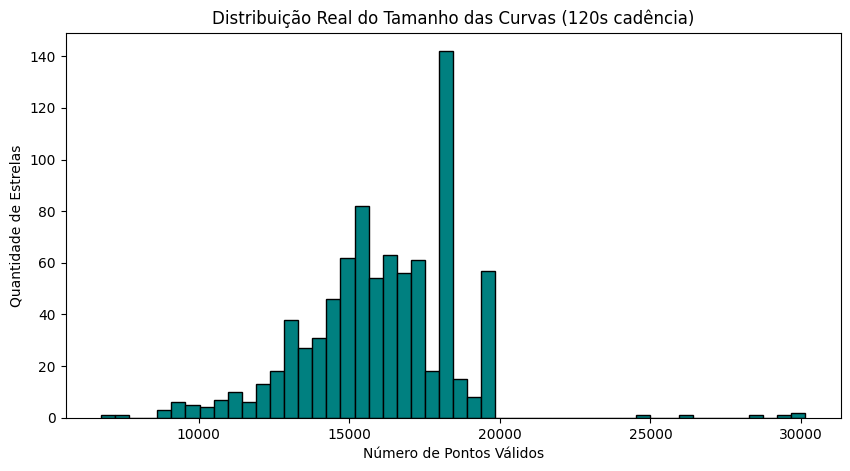

Média de pontos: 16069
Mediana (o valor do meio): 16174
Tamanho Mínimo: 6757
Tamanho Máximo: 30147
Percentil 95: 19610 (95% dos arquivos são menores que isso)


In [118]:
tamanhos_reais = []

for path in arquivos:
    try:
        lc = read(str(path))
        fluxos = lc.flux.value
        
        # Remove NaNs para saber o tamanho real de dados úteis
        valid_mask = ~np.isnan(fluxos) & ~np.isinf(fluxos)
        tamanho_util = np.sum(valid_mask)
        
        tamanhos_reais.append(tamanho_util)
    except Exception as e:
        print(f"Erro ao ler {path.name}: {e}")

tamanhos = np.array(tamanhos_reais)

plt.figure(figsize=(10, 5))
plt.hist(tamanhos, bins=50, color='teal', edgecolor='black')
plt.title('Distribuição Real do Tamanho das Curvas (120s cadência)')
plt.xlabel('Número de Pontos Válidos')
plt.ylabel('Quantidade de Estrelas')
plt.show()

print(f"Média de pontos: {np.mean(tamanhos):.0f}")
print(f"Mediana (o valor do meio): {np.median(tamanhos):.0f}")
print(f"Tamanho Mínimo: {np.min(tamanhos)}")
print(f"Tamanho Máximo: {np.max(tamanhos)}")
print(f"Percentil 95: {np.percentile(tamanhos, 95):.0f} (95% dos arquivos são menores que isso)")

## Especificaçoes dos arquivos

In [119]:
max_size = 0
arquivo_gigante = None
fluxos_gigante = None
lc_gigante = None
amostra = arquivos[:100] if len(arquivos) > 100 else arquivos

for path in amostra:
    lc = read(str(path))
    fluxos = lc.flux.value
    
    # Usando .size em vez de len() para pegar todos os elementos, independente da dimensão
    tamanho_real = fluxos.size 
    
    if tamanho_real > max_size:
        max_size = tamanho_real
        arquivo_gigante = path
        fluxos_gigante = fluxos
        lc_gigante = lc

print(f"arquivo estranho: {arquivo_gigante.name}")
print(f"formato do vetor de fluxo: {fluxos_gigante.shape}")
print(f"total de elementos isolados: {fluxos_gigante.size}")
print(f"Missão / Setor: {lc_gigante.mission} / Setor {getattr(lc_gigante, 'sector', 'Desconhecido')}")
print(f"Colunas do arquivo: {lc_gigante.columns}")

# Verificando se é 1D ou 2D
if len(fluxos_gigante.shape) > 1:
    print("O dado não é uma linha do tempo 1D! Ele tem múltiplas dimensões (provavelmente matrizes de pixels ou múltiplas aberturas).")
else:
    print("É 1D, mas tem dados demais. Pode ser uma curva de luz concatenada de vários anos ou um erro de salvamento.")

import warnings

# Suprime avisos de depreciação para manter o terminal limpo
warnings.filterwarnings('ignore')

BASE_POS = Path('../dados/train/positives')
BASE_NEG = Path('../dados/train/negatives')

def teste_1_flux_origin():
    """Verifica qual coluna de fluxo a biblioteca está usando por padrão."""
    path = list(BASE_POS.glob('*.fits'))[0]
    lc = read(str(path))
    origem = lc.meta.get('FLUX_ORIGIN', 'Desconhecido')
    print("Origem do Fluxo:")
    print(f"O lc.flux está puxando a coluna: {origem} (O ideal é pdcsap_flux)\n")

teste_1_flux_origin()

arquivo estranho: TIC_33595516.fits
formato do vetor de fluxo: (29581,)
total de elementos isolados: 29581
Missão / Setor: TESS / Setor 97
Colunas do arquivo: <TableColumns names=('time','flux','flux_err','cadenceno','quality','centroid_col','centroid_row','mom_centr1','mom_centr2')>
É 1D, mas tem dados demais. Pode ser uma curva de luz concatenada de vários anos ou um erro de salvamento.
Origem do Fluxo:
O lc.flux está puxando a coluna: lightkurve.LightCurve.to_fits() (O ideal é pdcsap_flux)



### Fluxo SAP ou PDCSAP

O teste retornou lightkurve.LightCurve.to_fits(). Isso não significa que os dados estão errados, mas revela um comportamento da biblioteca: quando você usou lc.to_fits() no script de download original, o lightkurve pegou o fluxo PDCSAP (que é o padrão) e o salvou em um arquivo FITS genérico, apagando a "etiqueta" da NASA que dizia que era PDCSAP. Quando usamos author="SPOC", o arquivo .fits baixa ambos. Mas quando chama lc.flux.value, a biblioteca lightkurve usa o PDCSAP por padrão. Não há mistura, você está usando o dado mais limpo possível.

## Pré-processamento feito nos códigos do qusi

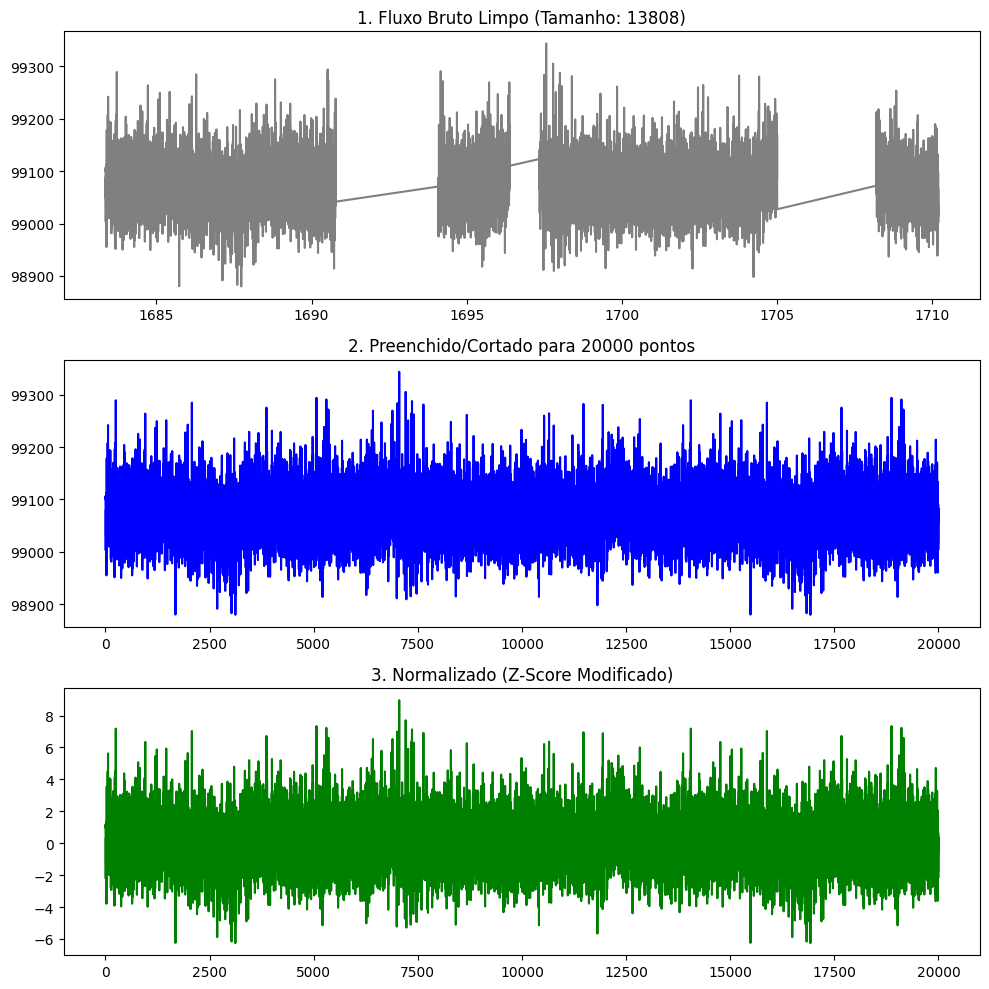

Tipo final: <class 'torch.Tensor'>
Formato (Shape) final que entra na rede neural: torch.Size([20000, 1])


In [120]:
# Lê o arquivo bruto (Objeto Lightkurve)
lc = read(exemplo_path)
tempos_brutos = lc.time.value
fluxos_brutos = lc.flux.value

# Passo 1: Limpa NaNs (Vetor Numpy)
valid_mask = ~np.isnan(fluxos_brutos) & ~np.isinf(fluxos_brutos)
fluxos_limpos = fluxos_brutos[valid_mask]
tempos_limpos = tempos_brutos[valid_mask]

# Passo 2 e 3: Corta/Preenche para 20000 pontos
length = 20000
if len(fluxos_limpos) < length:
    repeats = (length // len(fluxos_limpos)) + 1
    fluxos_pad = np.tile(fluxos_limpos, repeats)[:length]
else:
    fluxos_pad = fluxos_limpos[:length]

# Passo 4: Normalização 
median = np.median(fluxos_pad)
mad = np.median(np.abs(fluxos_pad - median))
if mad == 0: mad = 1e-8
fluxos_norm = (fluxos_pad - median) / mad


fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(tempos_limpos, fluxos_limpos, color='gray')
axes[0].set_title(f"1. Fluxo Bruto Limpo (Tamanho: {len(fluxos_limpos)})")
axes[1].plot(fluxos_pad, color='blue')
axes[1].set_title(f"2. Preenchido/Cortado para {length} pontos")
axes[2].plot(fluxos_norm, color='green')
axes[2].set_title(f"3. Normalizado (Z-Score Modificado)")

plt.tight_layout()
plt.show()

# Passo 5: Converte para Tensor (O que o modelo Hadryss recebe de fato)
tensor_final = torch.tensor(fluxos_norm, dtype=torch.float32).unsqueeze(1)
print(f"Tipo final: {type(tensor_final)}")
print(f"Formato (Shape) final que entra na rede neural: {tensor_final.shape}")

## Plot das curvas de luz baixadas

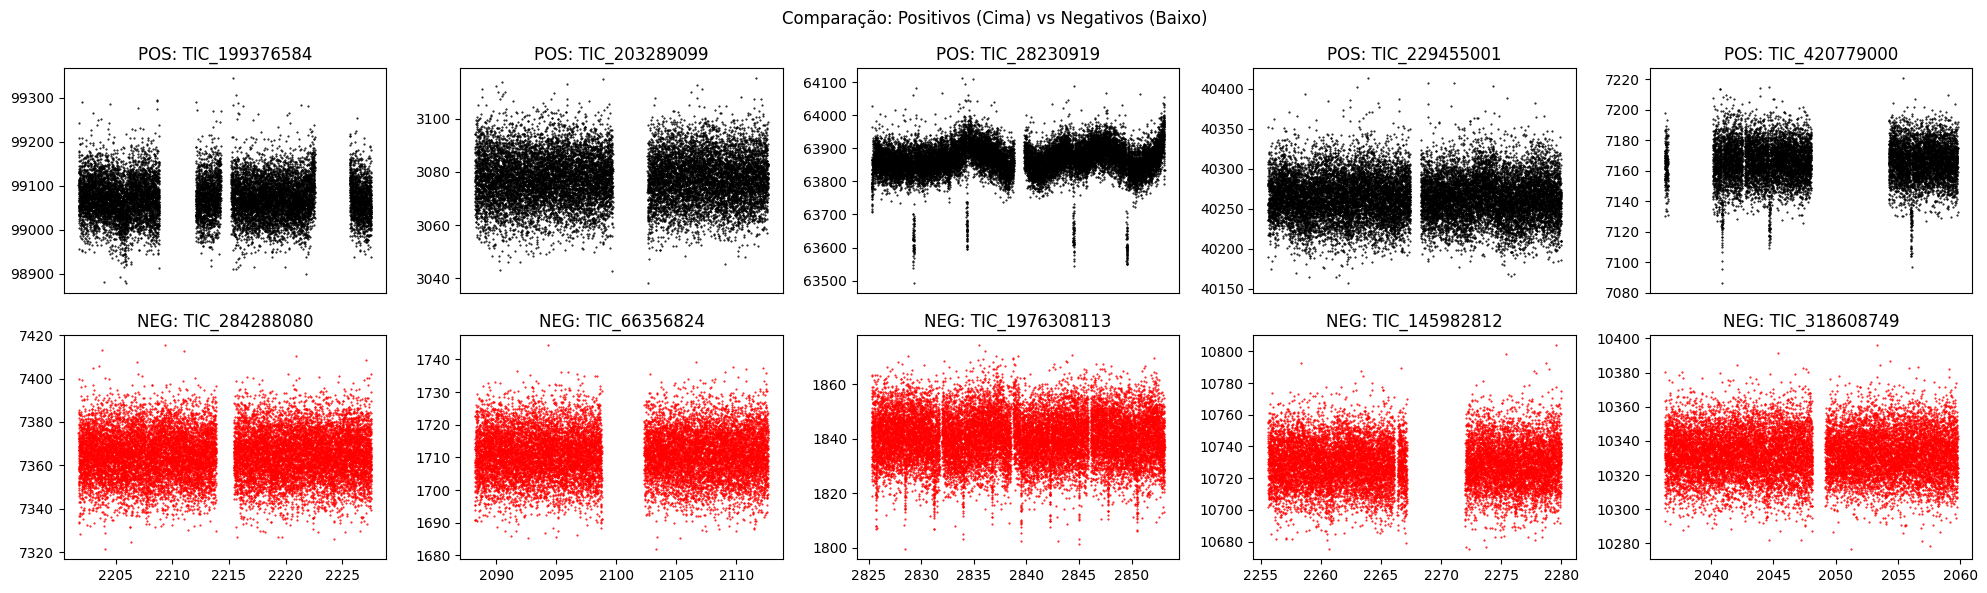

 O trânsito está realmente neste setor? 
Analisando: TIC_199376584.fits
Período mais forte encontrado: 17.70 dias


<Figure size 800x400 with 0 Axes>

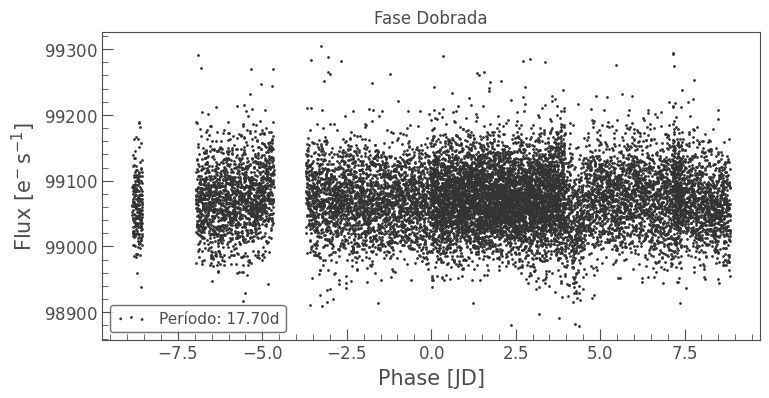

In [121]:
def teste_comparacao_visual_5():
    pos_paths = list(BASE_POS.glob('*.fits'))[:5]
    neg_paths = list(BASE_NEG.glob('*.fits'))[:5]
    fig, axes = plt.subplots(2, 5, figsize=(20, 6))
    fig.suptitle('Comparação: Positivos (Cima) vs Negativos (Baixo)')
    
    for i, path in enumerate(pos_paths):
        lc = read(str(path)).remove_nans()
        # Plota na linha 0 (cima)
        axes[0, i].plot(lc.time.value, lc.flux.value, 'k.', markersize=1)
        axes[0, i].set_title(f"POS: {path.name.replace('.fits','')}")
        axes[0, i].set_xticks([]) # Remove os números do eixo X pra ficar mais limpo
        
    for i, path in enumerate(neg_paths):
        lc = read(str(path)).remove_nans()
        # Plota na linha 1 (baixo)
        axes[1, i].plot(lc.time.value, lc.flux.value, 'r.', markersize=1)
        axes[1, i].set_title(f"NEG: {path.name.replace('.fits','')}")
        
    plt.tight_layout()
    plt.show()

def teste_bls_transit_check():
    #Tentar encontrar o período do planeta na curva.
    print(" O trânsito está realmente neste setor? ")
    path = list(BASE_POS.glob('*.fits'))[0]
    lc = read(str(path)).remove_nans().remove_outliers()
    
    # Roda o Box Least Squares
    periodogram = lc.to_periodogram(method='bls', period=np.arange(0.5, 20, 0.01))
    melhor_periodo = periodogram.period_at_max_power
    
    print(f"Analisando: {path.name}")
    print(f"Período mais forte encontrado: {melhor_periodo.value:.2f} dias")
    
    # Plota a curva dobrada (Phase Folded) no período encontrado
    lc_folded = lc.fold(period=melhor_periodo)
    
    plt.figure(figsize=(8, 4))
    lc_folded.scatter(label=f"Período: {melhor_periodo.value:.2f}d")
    plt.title(f"Fase Dobrada")
    plt.show()


if __name__ == '__main__':
    teste_comparacao_visual_5()
    teste_bls_transit_check()

Analisando: TIC_199376584.fits
Período mais forte encontrado: 17.70 dias


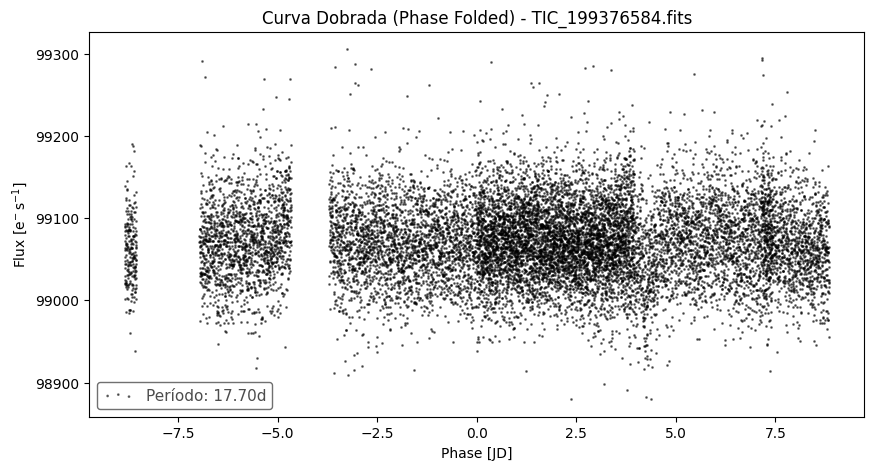

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from lightkurve import read

def teste_3_bls_transit_check_corrigido():
    path = list(Path('../dados/train/positives').glob('*.fits'))[0] # Pega o primeiro (TIC 199376584)
    lc = read(str(path)).remove_nans().remove_outliers()
    
    # 1. Roda o Box Least Squares
    periodogram = lc.to_periodogram(method='bls', period=np.arange(0.5, 20, 0.01))
    melhor_periodo = periodogram.period_at_max_power
    
    print(f"Analisando: {path.name}")
    print(f"Período mais forte encontrado: {melhor_periodo.value:.2f} dias")
    
    # 2. Dobra a curva no período encontrado
    lc_folded = lc.fold(period=melhor_periodo)
    
    # 3. Plotagem corrigida (forçando o lightkurve a usar o eixo do matplotlib)
    fig, ax = plt.subplots(figsize=(10, 5))
    lc_folded.scatter(ax=ax, label=f"Período: {melhor_periodo.value:.2f}d", color='black', alpha=0.5)
    ax.set_title(f"Curva Dobrada (Phase Folded) - {path.name}")
    plt.show()

teste_3_bls_transit_check_corrigido()

A. Stitching:
- Alterar o script de download para baixar todos os setores que existem para aquela estrela e costurá-los em uma curva gigante (garantindo que o trânsito estará lá). O problema é que a curva pode ficar com 200.000 pontos.

B. Phase Folding prévio:
- Em vez de dar a curva de tempo inteira para a rede, nós usamos a matemática (o código do teste acima) para "dobrar" todos os dados, transformar em uma única onda, e alimentar a rede neural apenas com a curva já dobrada (onde o trânsito ficará empilhado e gigantesco no meio da tela, mesmo que seja fraco).

## Wandb AI

- Curva azul (old force 1):
    - tutorial 1 do qusi, com dados deles. 
    - 15min

- Curva magenta (valiant disco 15):
    - rodei com 1300 positivos e 1300 negativos, mas estava sem filtro de cadencia entao os dados ficaram todos misturados.
    - 4h

- Curva verde (proud river 19):
    - adicionei o filtro de cadencia de 2min e binning = 10 (compressao da cruva de luz).
    - 25min


## Entender se os problemas estão nos dados ou no processamento:

1. plotar o antes e o depois do pre-processamento das 20 curvas ositivas e negativas (os transitos estão claros?)
2. entender a normalizacao no dataset.py
3. repassar cada passo e ver depois de cada passo a mudança que tem
4. comparar o codigo do tutorial com o novo e plotar os dados do tutorial!

OBS: o tutorial usou 1000 pontos apenas 

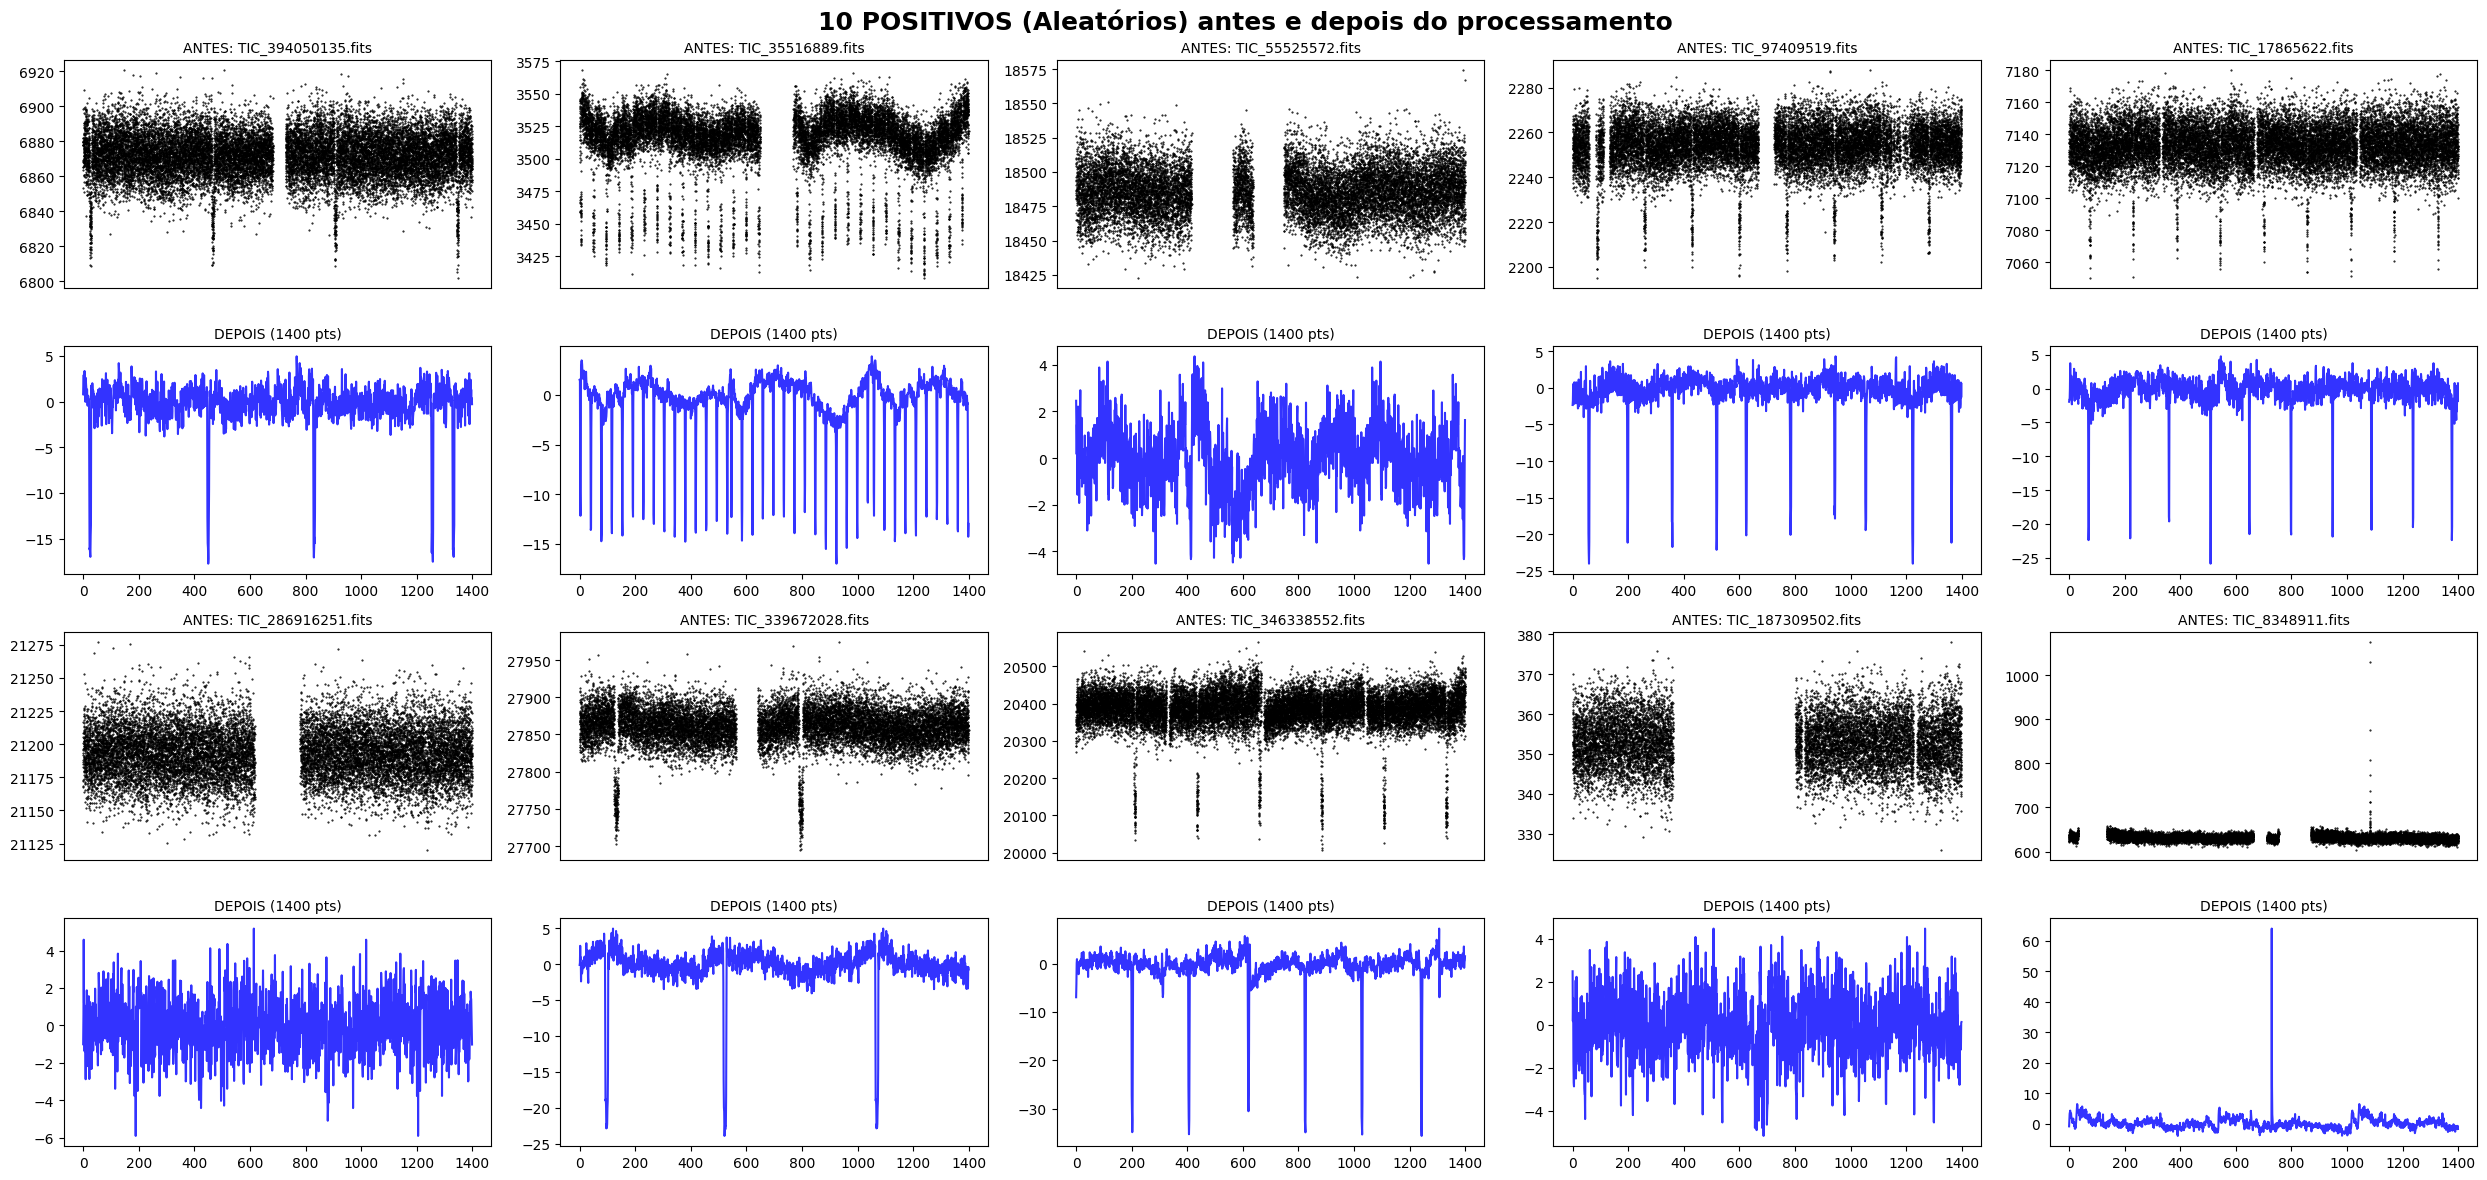

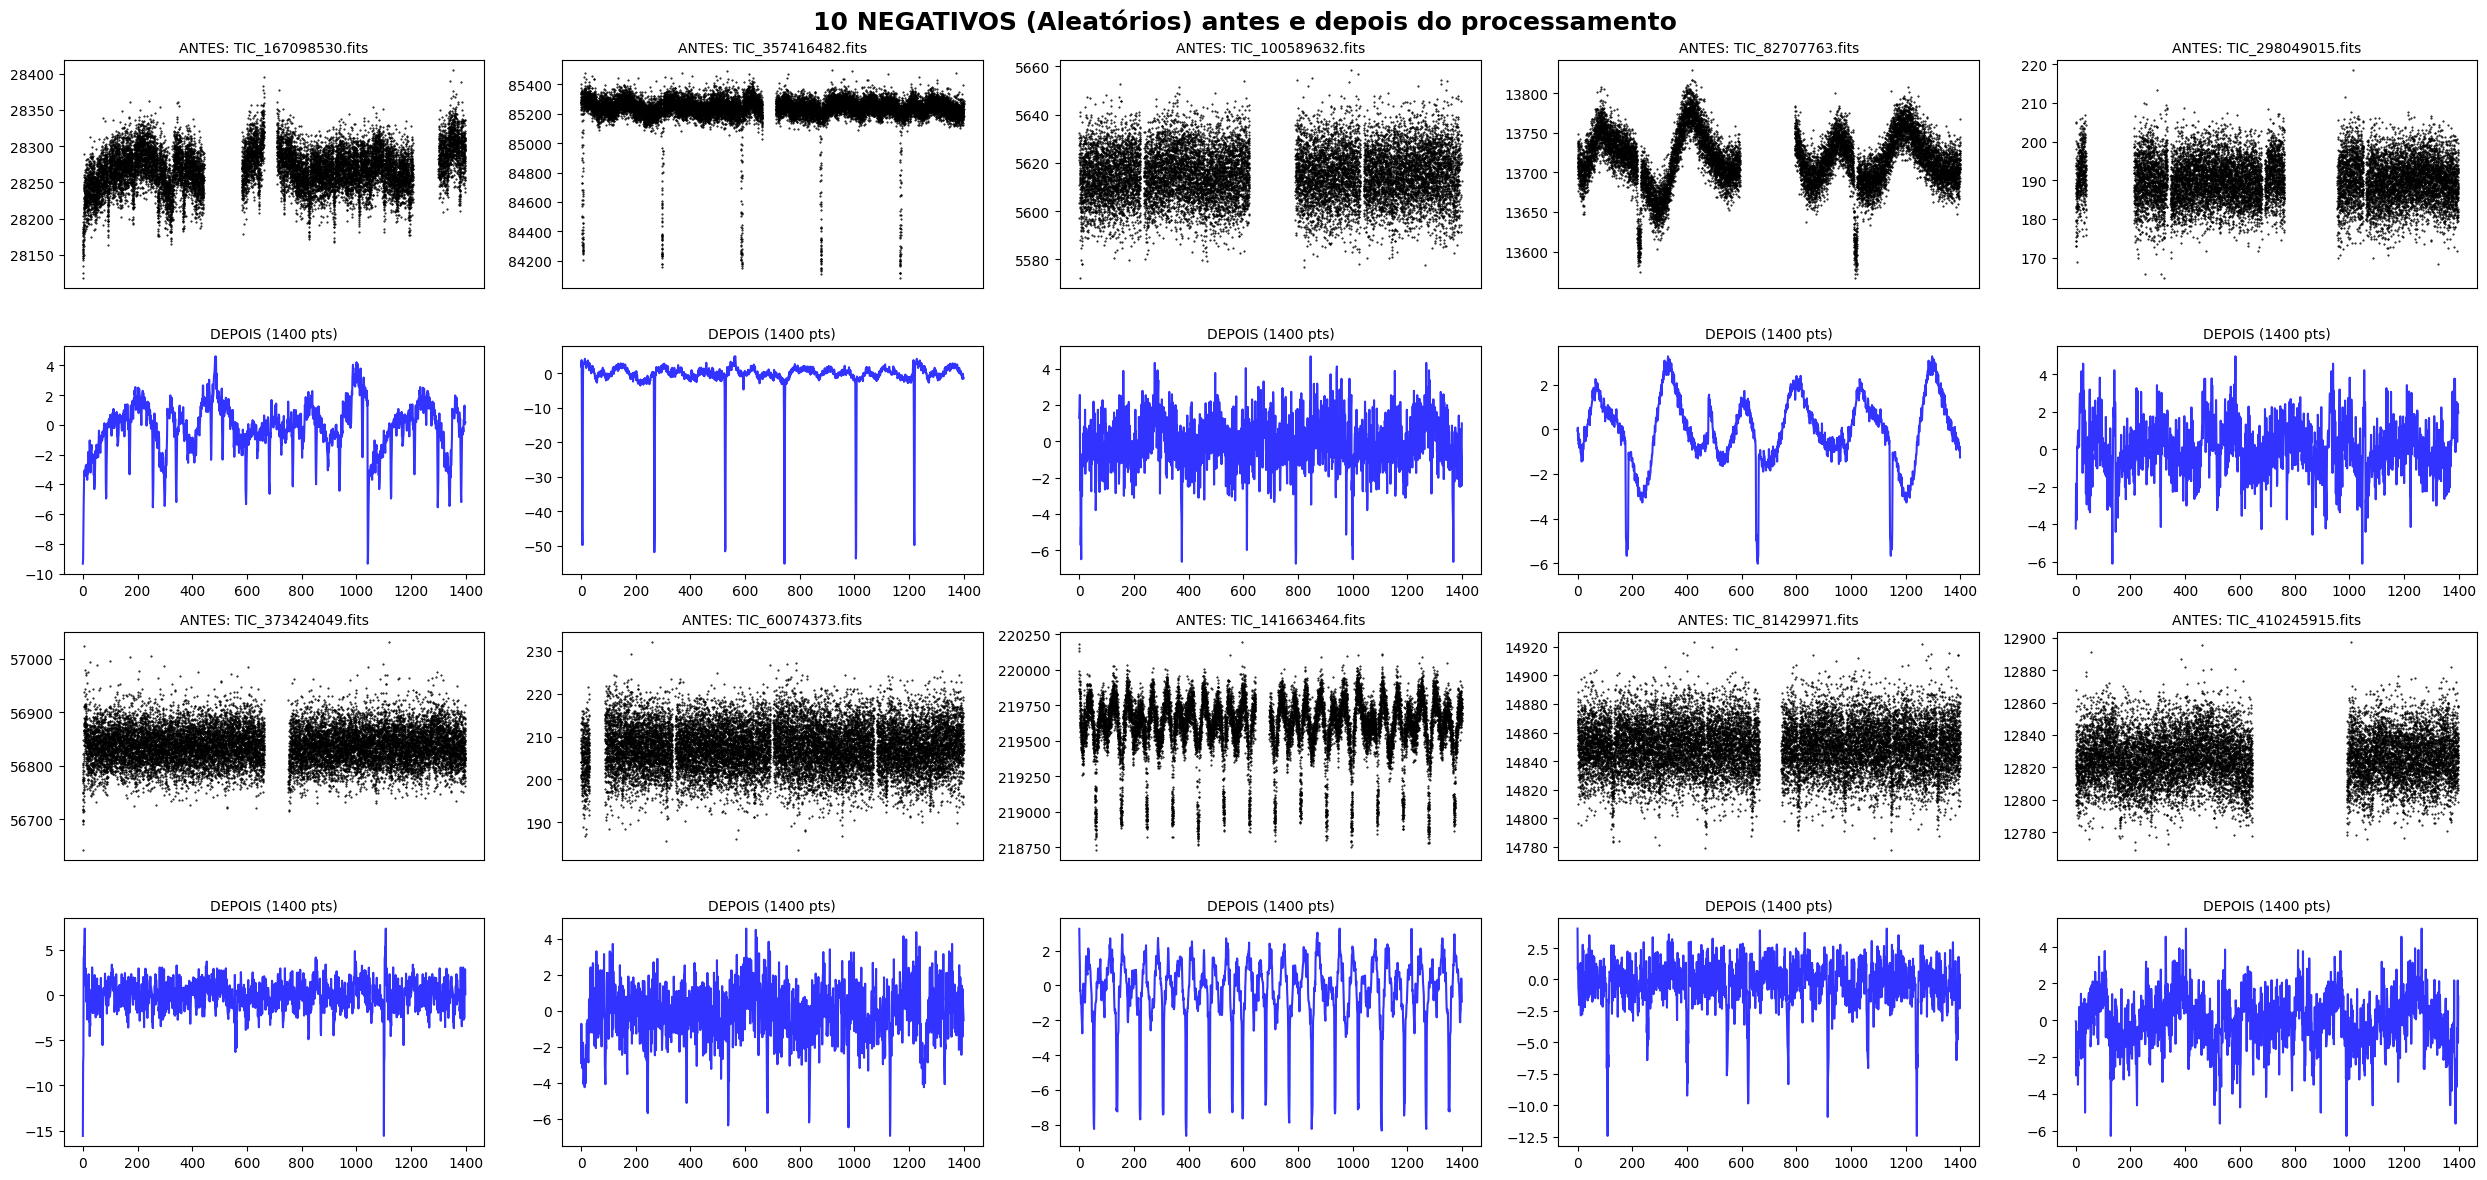

In [123]:
import random

BASE_POS = list(Path('../dados/train/positives').glob('*.fits'))
BASE_NEG = list(Path('../dados/train/negatives').glob('*.fits'))

def transformacao_simulada(fluxes, length=1400): #Cópia da lógica do dataset.py 
    valid_mask = ~np.isnan(fluxes) & ~np.isinf(fluxes)
    fluxes = fluxes[valid_mask]
    
    # Binning 15x
    bin_factor = 15
    if len(fluxes) >= bin_factor:
        sobra = len(fluxes) % bin_factor
        if sobra != 0: fluxes = fluxes[:-sobra]
        fluxes = fluxes.reshape(-1, bin_factor).mean(axis=1)
        
    # Padronização
    if len(fluxes) == 0: fluxes = np.zeros(length)
    elif len(fluxes) < length:
        repeats = (length // len(fluxes)) + 1
        fluxes = np.tile(fluxes, repeats)[:length]
    else: fluxes = fluxes[:length]
        
    # Normalização
    median = np.median(fluxes)
    mad = np.median(np.abs(fluxes - median))
    if mad == 0: mad = 1e-8
    return (fluxes - median) / mad

def plot_antes_depois(amostras, titulo):
    fig, axes = plt.subplots(4, 5, figsize=(25, 12))
    fig.suptitle(titulo, fontsize=18, fontweight='bold')
    
    for i, path in enumerate(amostras):
        # Lógica para distribuir nas linhas corretas
        linha_antes = 0 if i < 5 else 2
        linha_depois = 1 if i < 5 else 3
        coluna = i % 5
        
        try:
            lc = read(str(path))
            tempos, fluxos_brutos = lc.time.value, lc.flux.value
            fluxos_processados = transformacao_simulada(fluxos_brutos)
            
            # ANTES
            axes[linha_antes, coluna].plot(tempos, fluxos_brutos, 'k.', markersize=1)
            axes[linha_antes, coluna].set_title(f"ANTES: {path.name}", fontsize=10)
            axes[linha_antes, coluna].set_xticks([])
            
            # DEPOIS
            axes[linha_depois, coluna].plot(fluxos_processados, 'b-', alpha=0.8)
            axes[linha_depois, coluna].set_title(f"DEPOIS ({len(fluxos_processados)} pts)", fontsize=10)
            
        except Exception as e:
            axes[linha_antes, coluna].set_title(f"ERRO: {path.name}")
            axes[linha_depois, coluna].set_title("ERRO")
            print(f"Erro em {path.name}: {e}")
        
    plt.tight_layout()
    plt.show()

# Sorteia 10 aleatórios e plota
plot_antes_depois(random.sample(BASE_POS, 10), "10 POSITIVOS (Aleatórios) antes e depois do processamento")
plot_antes_depois(random.sample(BASE_NEG, 10), "10 NEGATIVOS (Aleatórios) antes e depois do processamento")

In [127]:

path = Path('../dados/train/positives/TIC_8348911.fits')
lc = read(str(path))
fluxos = lc.flux.value
    
    # Usando .size em vez de len() para pegar todos os elementos, independente da dimensão
tamanho_real = fluxos.size 

max_size = tamanho_real
arquivo_gigante = path
fluxos_gigante = fluxos
lc_gigante = lc

print(f"arquivo estranho: {arquivo_gigante.name}")
print(f"formato do vetor de fluxo: {fluxos_gigante.shape}")
print(f"total de elementos isolados: {fluxos_gigante.size}")
print(f"Missão / Setor: {lc_gigante.mission} / Setor {getattr(lc_gigante, 'sector', 'Desconhecido')}")
print(f"Colunas do arquivo: {lc_gigante.columns}")


arquivo estranho: TIC_8348911.fits
formato do vetor de fluxo: (15231,)
total de elementos isolados: 15231
Missão / Setor: TESS / Setor 24
Colunas do arquivo: <TableColumns names=('time','flux','flux_err','cadenceno','quality','centroid_col','centroid_row','mom_centr1','mom_centr2')>


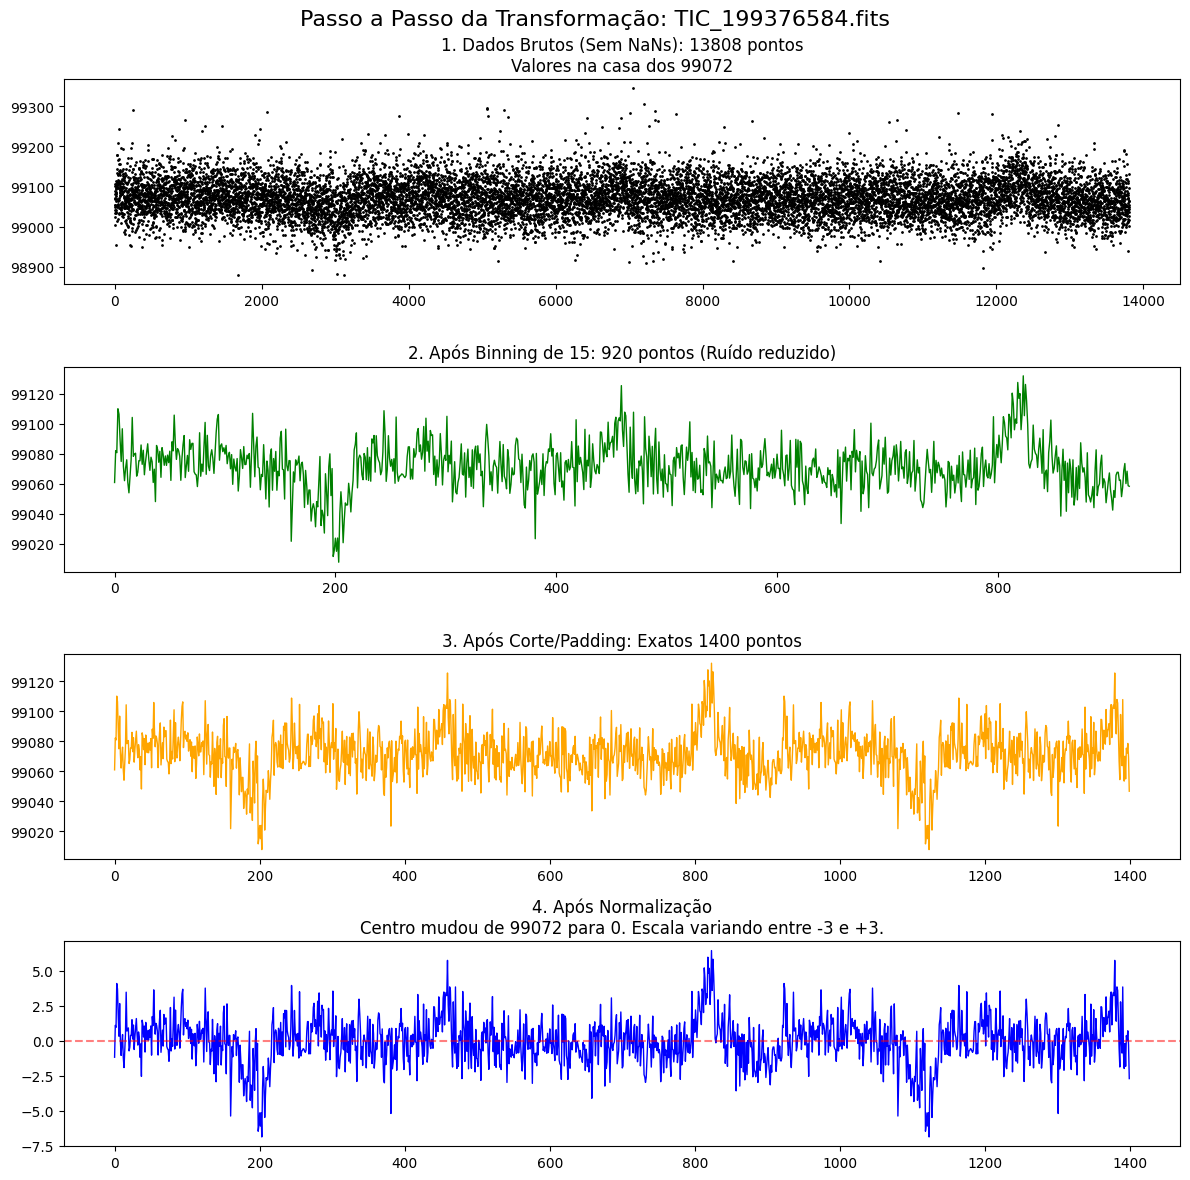

In [124]:
#primeiro arquivo positivo
path = list(Path('../dados/train/positives').glob('*.fits'))[0]
lc = read(str(path))
tempos_brutos, fluxos_brutos = lc.time.value, lc.flux.value
fig, axes = plt.subplots(4, 1, figsize=(12, 12))
fig.suptitle(f'Passo a Passo da Transformação: {path.name}', fontsize=16)

# PASSO 1: Bruto (Sem NaNs)
valid_mask = ~np.isnan(fluxos_brutos) & ~np.isinf(fluxos_brutos)
f1 = fluxos_brutos[valid_mask]
axes[0].plot(f1, 'k.', markersize=2)
axes[0].set_title(f"1. Dados Brutos (Sem NaNs): {len(f1)} pontos\nValores na casa dos {np.mean(f1):.0f}")

# PASSO 2: Binning (Compressão 15x)
sobra = len(f1) % 15
if sobra != 0: f1 = f1[:-sobra]
f2 = f1.reshape(-1, 15).mean(axis=1)
axes[1].plot(f2, 'g-', linewidth=1)
axes[1].set_title(f"2. Após Binning de 15: {len(f2)} pontos (Ruído reduzido)")

# PASSO 3: Corte/Preenchimento para 1400
length = 1400
if len(f2) < length:
    repeats = (length // len(f2)) + 1
    f3 = np.tile(f2, repeats)[:length]
else: f3 = f2[:length]
axes[2].plot(f3, 'orange', linewidth=1)
axes[2].set_title(f"3. Após Corte/Padding: Exatos {len(f3)} pontos")

# PASSO 4: Normalização 
median = np.median(f3)
mad = np.median(np.abs(f3 - median))
if mad == 0: mad = 1e-8
f4 = (f3 - median) / mad
axes[3].plot(f4, 'b-', linewidth=1)
axes[3].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[3].set_title(f"4. Após Normalização\nCentro mudou de {median:.0f} para 0. Escala variando entre -3 e +3.")
plt.tight_layout()
plt.show()

meus dados (2 min cadência): 13808 pontos
dados do tutorial: 3548 pontos


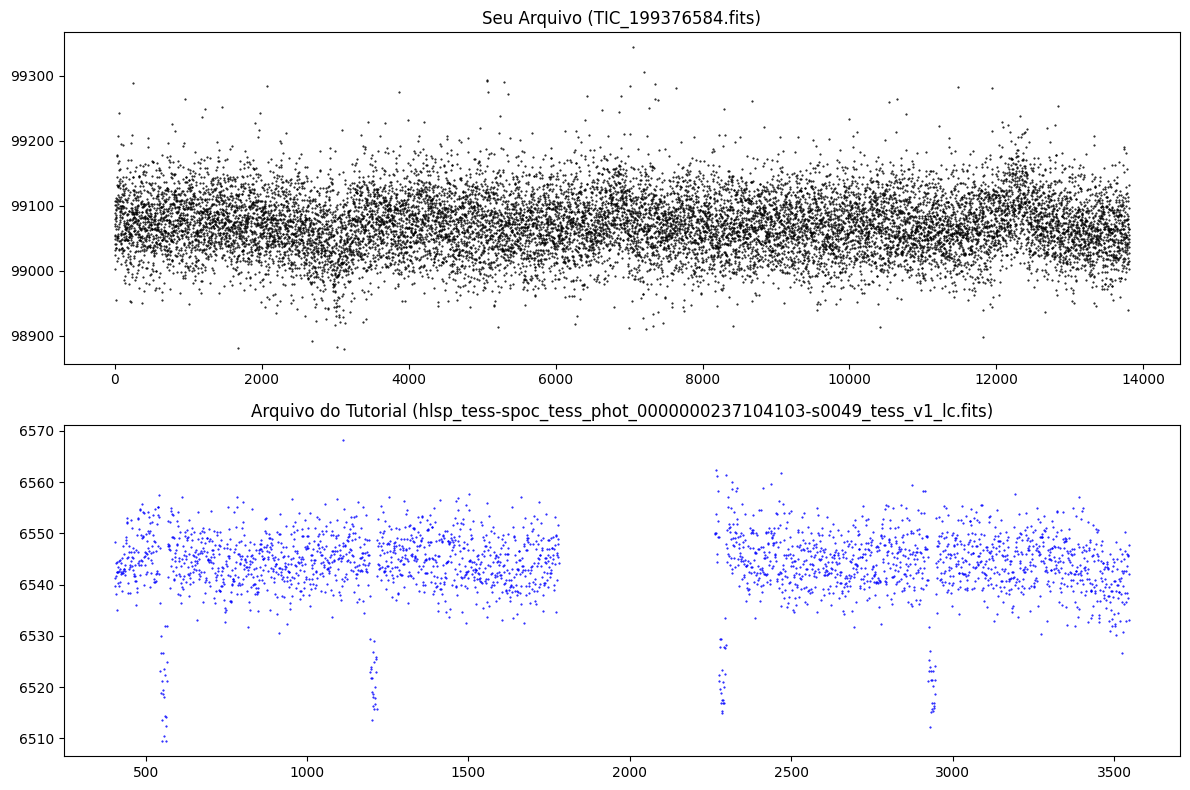

In [125]:
try:
    #arquivo baixado pelo lightkurve
    seu_path = list(Path('../dados/train/positives').glob('*.fits'))[0]
    sua_lc = read(str(seu_path))
    seus_tempos, seus_fluxos = sua_lc.time.value, sua_lc.flux.value
    
    #arquivo baixado pelo qusi (tutorial)
    tut_path = list(Path('../data/spoc_transit_experiment/train/positives').glob('*.fits'))[0]
    tut_lc = read(str(tut_path), flux_column='pdcsap_flux') 
    tut_tempos, tut_fluxos = tut_lc.time.value, tut_lc.flux.value

    #comparação
    print(f"meus dados (2 min cadência): {len(seus_fluxos)} pontos")
    print(f"dados do tutorial: {len(tut_fluxos)} pontos")

    #plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    axes[0].plot(seus_fluxos, 'k.', markersize=1)
    axes[0].set_title(f"Seu Arquivo ({seu_path.name})")
    axes[1].plot(tut_fluxos, 'b.', markersize=1)
    axes[1].set_title(f"Arquivo do Tutorial ({tut_path.name})")
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"ERRO: {e}")

Na parte de normalização é melhor:
TIRAr A MEDIA E DIVIDir PELO DESVIO PADRAO
Usar o pacote de SCIKIT-LEARN que já faz isso, não precisa fazer manual
 
Vamos fazer a aumentação dos dados, pq o tutorial tem no train 1300 positivos e 6000 negativos e validation e test tem 200 curvas de luz positivos e 600 negativos (total 8900). Então vamos adicionar mais 3 formas de aumentar os dados, que os codigos do qusi fazem:
-> cortar a curva e muda de lugar:
def randomly_roll_light_curve_observation(light_curve_observation: LightCurveObservation) -> LightCurveObservation:
    """
    Randomly rolls a light curve observation. That is, a random position in the light curve is chosen, the light curve
    is split at that point, and the order of the two halves are swapped.
 
    :param light_curve_observation: The light curve observation.
    :return: The light curve observation with the rolled light curve.
    """
    light_curve_observation = deepcopy(light_curve_observation)
    light_curve_observation.light_curve = randomly_roll_light_curve(light_curve_observation.light_curve)
    return light_curve_observation
 
-> corta a curva e tira alguns pontos aleatórios
 
-> PEGAR MAIS SETORES P AUMENTAR OS DADOS DE CURVAS DE LUZ (os setores vao ficar em curvas de luz separadas!)
 
Verificar se nos codigos do qusi não tem outra tecnica de aumentacao de dados.
CONFERIR SE TEM TICS REPETIDOS DO TUTORIAL (pelos arquivos que tem o tic no nome)

COLOCAR validação E TESTE JUNTOS ->  Precisa aparecer no wandb ai o VAL LOSS E LOSS JUNTO
 
Mudar os parametros (aumentar o batch size e etc) porque pelos graficos do wandb, parece que precisa rodar mais pq demora mais tempo para convergir.


In [ ]:
import torch
from sklearn.preprocessing import StandardScaler 

def custom_transform(observation, length=1400, randomize=False):
    try: 
        fluxes = observation.light_curve.fluxes
        label = observation.label
        
        #NaNs
        valid_mask = ~np.isnan(fluxes) & ~np.isinf(fluxes)
        mediana_bruta = np.median(fluxes[valid_mask]) if any(valid_mask) else 0
        fluxes = np.where(valid_mask, fluxes, mediana_bruta)

        #Binning (Compressão de 15x -> Cadência de 30 min) (média de 15 pontos = 1 ponto)
        bin_factor = 15
        if len(fluxes) >= bin_factor:
            sobra = len(fluxes) % bin_factor
            if sobra != 0: fluxes = fluxes[:-sobra]
            fluxes = fluxes.reshape(-1, bin_factor).mean(axis=1)

        # Alterações para Data Augmentation (aplicado só no treino)

        #Tirar pontos aleatórios (apaga 10% dos dados)
        if randomize and len(fluxes) > 0:
            
            #Dropout: Tira pontos aleatórios (apaga 10% dos dados)
            dropout_mask = np.random.rand(len(fluxes)) > 0.10 
            fluxes = fluxes[dropout_mask]

            #Roll: Corta a curva e muda de lugar (Shift no tempo)
            roll_amount = np.random.randint(0, len(fluxes))
            fluxes = np.roll(fluxes, roll_amount)

        # Normalização com Scikit-learn (Média dividida pelo Desvio Padrão)
        if len(fluxes) > 0:
            scaler = StandardScaler()
            fluxes = scaler.fit_transform(fluxes.reshape(-1, 1)).flatten()

        if len(fluxes) == 0:
            fluxes_final = np.zeros(length, dtype=np.float32)
        elif len(fluxes) < length:
            pad_size = length - len(fluxes)
            fluxes_final = np.pad(fluxes, (0, pad_size), mode='constant', constant_values=0)
        else:
            fluxes_final = fluxes[:length]
    
        #Converte para Tensores PyTorch
        fluxes_native = np.ascontiguousarray(fluxes_final, dtype=np.float32)
        fluxes_tensor = torch.tensor(fluxes_native).unsqueeze(1)
        label_tensor = torch.tensor(label, dtype=torch.float32)
        
        return fluxes_tensor, label_tensor
  
    except Exception as e:
        print(f"Erro na transformação dos dados: {e}")
        # Retorna tensor vazio para não travar o loop de treino
        return torch.zeros(length, 1), torch.tensor(observation.label, dtype=torch.float32)